In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))


https://www.geeksforgeeks.org/titanic-survival-prediction-using-tensorflow-in-python/

In this article, we will learn to predict the survival chances of the Titanic passengers using the given information about their sex, age, etc. As this is a classification task we will be using random forest.
There will be three main steps in this experiment:
1.	Feature Engineering
2.	Imputation
3.	Training and Prediction



# Dataset

1.	The dataset for this experiment is freely available on the Kaggle website.
2.	Download the dataset from this link
3.	https://www.kaggle.com/competitions/titanic/data?select=train.csv
4.	Once the dataset is downloaded it is divided into three CSV files gender submission.csv, train.csv and test.csv



# Importing Libraries and Initial setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline
warnings.filterwarnings('ignore')


Now let’s read the training and test data using the pandas data frame.

In [ ]:
train = pd.read_csv('https://raw.githubusercontent.com/tamanna18/Titanic-Survival-prediction/main/data/train.csv')

In [ ]:
train.shape

(891, 12)

In [ ]:
test = pd.read_csv('https://raw.githubusercontent.com/tamanna18/Titanic-Survival-prediction/main/data/test.csv')

In [ ]:
test.shape

(418, 11)

To know the information about each column like the data type, etc we use the df.info() function.

In [ ]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


1.	Now let’s see if there are any NULL values present in the dataset.
2.	This can be checked using the isnull() function.
3.	It yields the following output.


In [ ]:
train.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Visualization
Now let us visualize the data using some pie charts and histograms to get a proper understanding of the data.



Let us first visualize the number of survivors and death counts.

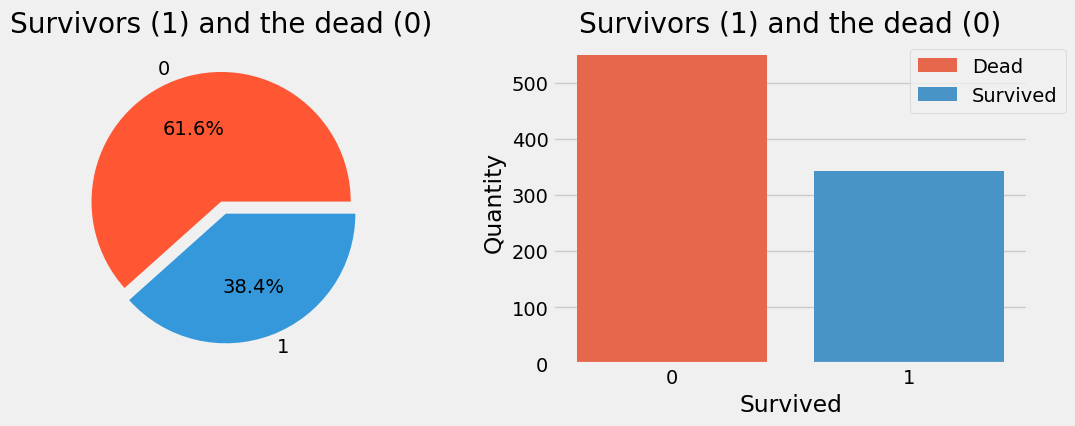

In [ ]:
# Define colors
colors = ['#FF5733', '#3498db']  # Orange and Blue

f, ax = plt.subplots(1, 2, figsize=(12, 4))
train['Survived'].value_counts().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=False, colors=colors)
ax[0].set_title('Survivors (1) and the dead (0)')
ax[0].set_ylabel('')

sns.countplot(x='Survived', data=train, ax=ax[1], palette=colors)  # Pass x explicitly
ax[1].set_ylabel('Quantity')
ax[1].set_title('Survivors (1) and the dead (0)')

# Setting legend
ax[1].legend(labels=['Dead', 'Survived'], loc='upper right', bbox_to_anchor=(1.1, 1))

plt.show()

**Sex feature**

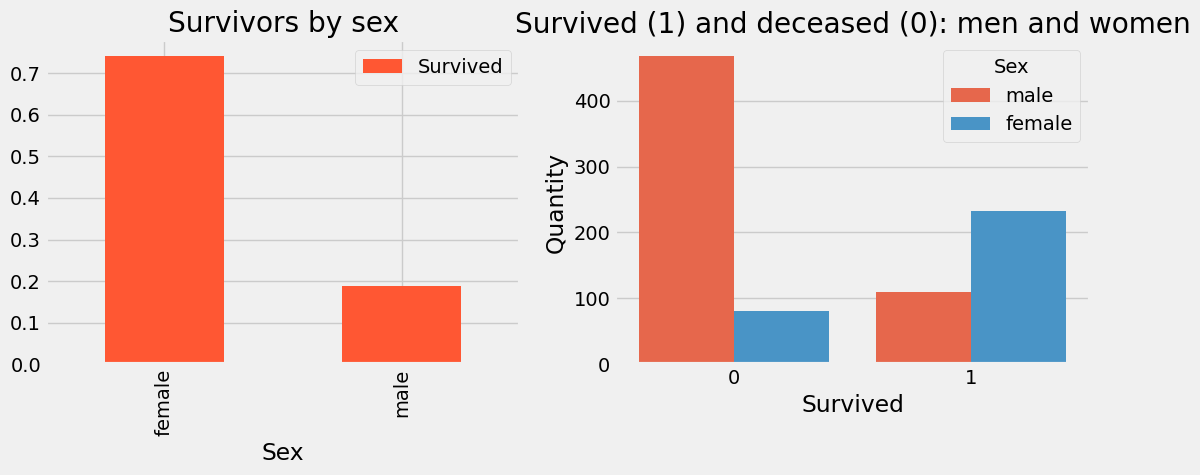

In [ ]:
# Define colors
bar_colors = ['#FF5733', '#3498db']  # Orange and Blue
countplot_colors = ['#FF5733', '#3498db']  # Orange and Blue

f, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
train[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0], color=bar_colors)
ax[0].set_title('Survivors by sex')

# Countplot for males and females
sns.countplot(x='Survived', hue='Sex', data=train, palette=countplot_colors, ax=ax[1])
ax[1].set_ylabel('Quantity')  # Set ylabel for the second subplot
ax[1].set_title('Survived (1) and deceased (0): men and women')  # Set title for the second subplot

plt.legend(title='Sex')
plt.show()


# Feature Engineering

Now let’s see which columns should we drop and/or modify for the model to predict the testing data. The main tasks in this step is to drop unnecessary features and to convert string data into the numerical category for easier training.

We’ll start off by dropping the Cabin feature since not a lot more useful information can be extracted from it. But we will make a new column from the Cabins column to see if there was cabin information allotted or not.

In [ ]:
# Create a new column cabinbool indicating
# if the cabin value was given or was NaN
train["CabinBool"] = (train["Cabin"].notnull().astype('int'))
test["CabinBool"] = (test["Cabin"].notnull().astype('int'))

# Delete the column 'Cabin' from test
# and train dataset
train = train.drop(['Cabin'], axis=1)
test = test.drop(['Cabin'], axis=1)


We can also drop the Ticket feature since it’s unlikely to yield any useful information

In [ ]:
train = train.drop(['Ticket'], axis=1)
test = test.drop(['Ticket'], axis=1)


There are missing values in the Embarked feature. For that, we will replace the NULL values with ‘S’ as the number of Embarks for ‘S’ are higher than the other two.

In [ ]:
# replacing the missing values in
# the Embarked feature with S
train = train.fillna({"Embarked": "S"})


We will now sort the age into groups. We will combine the age groups of the people and categorize them into the same groups. BY doing so we will be having fewer categories and will have a better prediction since it will be a categorical dataset.

In [ ]:
# sort the ages into logical categories
train["Age"] = train["Age"].fillna(-0.5)
test["Age"] = test["Age"].fillna(-0.5)
bins = [-1, 0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager',
		'Student', 'Young Adult', 'Adult', 'Senior']
train['AgeGroup'] = pd.cut(train["Age"], bins, labels=labels)
test['AgeGroup'] = pd.cut(test["Age"], bins, labels=labels)


In the ‘title’ column for both the test and train set, we will categorize them into an equal number of classes. Then we will assign numerical values to the title for convenience of model training.

In [ ]:
# create a combined group of both datasets
combine = [train, test]

# extract a title for each Name in the
# train and test datasets
for dataset in combine:
	dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

pd.crosstab(train['Title'], train['Sex'])

# replace various titles with more common names
for dataset in combine:
	dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col',
												'Don', 'Dr', 'Major',
												'Rev', 'Jonkheer', 'Dona'],
												'Rare')

	dataset['Title'] = dataset['Title'].replace(
		['Countess', 'Lady', 'Sir'], 'Royal')
	dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
	dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
	dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

# map each of the title groups to a numerical value
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3,
				"Master": 4, "Royal": 5, "Rare": 6}
for dataset in combine:
	dataset['Title'] = dataset['Title'].map(title_mapping)
	dataset['Title'] = dataset['Title'].fillna(0)


Now using the title information we can fill in the missing age values.

In [ ]:
mr_age = train[train["Title"] == 1]["AgeGroup"].mode() # Young Adult
miss_age = train[train["Title"] == 2]["AgeGroup"].mode() # Student
mrs_age = train[train["Title"] == 3]["AgeGroup"].mode() # Adult
master_age = train[train["Title"] == 4]["AgeGroup"].mode() # Baby
royal_age = train[train["Title"] == 5]["AgeGroup"].mode() # Adult
rare_age = train[train["Title"] == 6]["AgeGroup"].mode() # Adult

age_title_mapping = {1: "Young Adult", 2: "Student",
					3: "Adult", 4: "Baby", 5: "Adult", 6: "Adult"}

for x in range(len(train["AgeGroup"])):
	if train["AgeGroup"][x] == "Unknown":
		train["AgeGroup"][x] = age_title_mapping[train["Title"][x]]

for x in range(len(test["AgeGroup"])):
	if test["AgeGroup"][x] == "Unknown":
		test["AgeGroup"][x] = age_title_mapping[test["Title"][x]]


Now assign a numerical value to each age category. Once we have mapped the age into different categories we do not need the age feature. Hence drop it

In [ ]:
# map each Age value to a numerical value
age_mapping = {'Baby': 1, 'Child': 2, 'Teenager': 3,
			'Student': 4, 'Young Adult': 5, 'Adult': 6,
			'Senior': 7}
train['AgeGroup'] = train['AgeGroup'].map(age_mapping)
test['AgeGroup'] = test['AgeGroup'].map(age_mapping)

train.head()

# dropping the Age feature for now, might change
train = train.drop(['Age'], axis=1)
test = test.drop(['Age'], axis=1)


Drop the name feature since it contains no more useful information.

In [ ]:
train = train.drop(['Name'], axis=1)
test = test.drop(['Name'], axis=1)


Assign numerical values to sex and embarks categories\

In [ ]:
sex_mapping = {"male": 0, "female": 1}
train['Sex'] = train['Sex'].map(sex_mapping)
test['Sex'] = test['Sex'].map(sex_mapping)

embarked_mapping = {"S": 1, "C": 2, "Q": 3}
train['Embarked'] = train['Embarked'].map(embarked_mapping)
test['Embarked'] = test['Embarked'].map(embarked_mapping)


Fill in the missing Fare value in the test set based on the mean fare for that P-class

In [ ]:
for x in range(len(test["Fare"])):
	if pd.isnull(test["Fare"][x]):
		pclass = test["Pclass"][x] # Pclass = 3
		test["Fare"][x] = round(
			train[train["Pclass"] == pclass]["Fare"].mean(), 4)

# map Fare values into groups of
# numerical values
train['FareBand'] = pd.qcut(train['Fare'], 4,
							labels=[1, 2, 3, 4])
test['FareBand'] = pd.qcut(test['Fare'], 4,
						labels=[1, 2, 3, 4])

# drop Fare values
train = train.drop(['Fare'], axis=1)
test = test.drop(['Fare'], axis=1)


Now we are done with the feature engineering

# Model Training
We will be using Random forest as the algorithm of choice to perform model training. Before that, we will split the data in an 80:20 ratio as a train-test split. For that, we will use the train_test_split() from the sklearn library.

In [ ]:
from sklearn.model_selection import train_test_split

# Drop the Survived and PassengerId
# column from the trainset
predictors = train.drop(['Survived', 'PassengerId'], axis=1)
target = train["Survived"]
x_train, x_val, y_train, y_val = train_test_split(
	predictors, target, test_size=0.2, random_state=0)


Now import the random forest function from the ensemble module of sklearn and for the training set.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

randomforest = RandomForestClassifier()

# Fit the training data along with its output
randomforest.fit(x_train, y_train)
y_pred = randomforest.predict(x_val)

# Find the accuracy score of the model
acc_randomforest = round(accuracy_score(y_pred, y_val) * 100, 2)
print(acc_randomforest)


83.8


With this, we got an accuracy of 83.25%

# Prediction
We are provided with the testing dataset on which we have to perform the prediction. To predict, we will pass the test dataset into our trained model and save it into a CSV file containing the information, passengerid and survival. PassengerId will be the passengerid of the passengers in the test data and the survival will column will be either 0 or 1.

In [ ]:
ids = test['PassengerId']
predictions = randomforest.predict(test.drop('PassengerId', axis=1))

# set the output as a dataframe and convert
# to csv file named resultfile.csv
output = pd.DataFrame({'PassengerId': ids, 'Survived': predictions})
output.to_csv('resultfile.csv', index=False)


This will create a resultfile.csv which looks like this

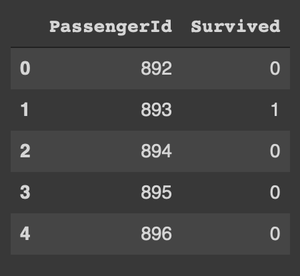

In [ ]:
results = pd.read_csv('resultfile.csv')

In [ ]:
results.shape

(418, 2)

In [ ]:
results.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0


In [ ]:
results.iloc[77]


PassengerId    969
Survived         1
Name: 77, dtype: int64

This line will return the data for the 78th row of the DataFrame results without explicitly using the print() function.

In [ ]:
# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Get current time in IST for the last cell entry
now_ist_last = datetime.now(ist)

# Format the current date and time for the last cell
formatted_date_last = now_ist_last.strftime('%Y-%m-%d')
formatted_time_last = now_ist_last.strftime('%H:%M:%S %Z%z')

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Display the last cell entry time in bold (default color)
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))


In [ ]:
# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Extract hours, minutes, and seconds from the time difference
hours = time_diff.seconds // 3600  # Total seconds divided by 3600 to get hours
minutes = (time_diff.seconds % 3600) // 60  # Remainder divided by 60 to get minutes
seconds = time_diff.seconds % 60  # Remainder gives the number of seconds

# Display the statement for total time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the first and last cell entry times along with the total time taken in HH:MM:SS format
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))
display(Markdown(f'**Time Taken: {hours} hour(s), {minutes} minute(s), and {seconds} second(s)**'))


## Notebook Q&A

**Q1: What is the main goal of this notebook?**

**A1:**
1. Predict the survival chances of Titanic passengers.
2. Use passenger information like sex, age, etc.
3. Employ the Random Forest algorithm for classification.

**Q2: What are the main steps involved in this experiment?**

**A2:**
1. Feature Engineering
2. Imputation (handling missing values)
3. Training and Prediction

**Q3: Where did the dataset for this experiment come from?**

**A3:**
1. The dataset is from Kaggle.
2. Specifically, the Titanic competition dataset.
3. The data is divided into `gender_submission.csv`, `train.csv`, and `test.csv`.

**Q4: What are the initial steps taken after importing libraries?**

**A4:**
1. Reading the `train.csv` and `test.csv` files into pandas DataFrames.
2. Checking the shape (number of rows and columns) of the DataFrames.
3. Using `.info()` to get data types and non-null counts.
4. Using `.isnull().sum()` to identify columns with missing values.

**Q5: Which columns had missing values in the training dataset and how were they handled?**

**A5:**
1. `Age` had 177 missing values. These were initially filled with -0.5 and later categorized and imputed based on titles.
2. `Cabin` had 687 missing values. A new boolean column `CabinBool` was created, and the original `Cabin` column was dropped.
3. `Embarked` had 2 missing values. These were filled with 'S' as it was the most frequent value.

**Q6: What visualizations were used to understand the data?**

**A6:**
1. Pie chart and countplot to visualize the number of survivors and deceased.
2. Bar plot to show the survival rate by sex.
3. Countplot to show the survival count for each sex.

**Q7: What feature engineering steps were performed?**

**A7:**
1. Created `CabinBool` from the `Cabin` column and dropped `Cabin`.
2. Dropped the `Ticket` column.
3. Filled missing `Embarked` values with 'S'.
4. Categorized `Age` into groups (`AgeGroup`) and filled missing values based on `Title`. The original `Age` column was dropped.
5. Extracted and categorized `Title` from the `Name` column and mapped titles to numerical values. The `Name` column was dropped.
6. Mapped `Sex` and `Embarked` to numerical values.
7. Filled missing `Fare` values in the test set with the mean fare of the corresponding P-class.
8. Categorized `Fare` into `FareBand` and dropped the original `Fare` column.

**Q8: How was the data split for model training?**

**A8:**
1. The data was split into training and validation sets using `train_test_split`.
2. The `Survived` column was used as the target variable.
3. The `Survived` and `PassengerId` columns were dropped from the predictors.
4. A test size of 20% was used (`test_size=0.2`).

**Q9: Which machine learning algorithm was used for training and what was the accuracy?**

**A9:**
1. The Random Forest Classifier was used.
2. The accuracy on the validation set was approximately 83.8%.

**Q10: How was the prediction made on the test dataset and saved?**

**A10:**
1. The trained Random Forest model was used to predict survival on the `test` DataFrame (excluding the `PassengerId` column).
2. The predictions were combined with the `PassengerId` into a new DataFrame.
3. This DataFrame was saved to a CSV file named `resultfile.csv`.

## Interview Preparation Questions and Answers

Based on the techniques and concepts demonstrated in this notebook, here are some potential interview questions and how you could answer them.

**Q1: Can you explain the process of handling missing data in this notebook?**

**A1:**
1. We identified missing values in `Age`, `Cabin`, and `Embarked` using `isnull().sum()`.
2. For `Cabin`, we created a boolean feature indicating presence and then dropped the original column due to a high number of missing values.
3. For `Embarked`, we imputed the missing values with the mode ('S').
4. For `Age`, we initially filled missing values with -0.5 and then used the `Title` feature, which we extracted from the `Name` column, to impute more appropriate age group categories based on the typical age range for each title. Finally, we mapped these age groups to numerical values.

**Q2: Why did you perform feature engineering, and what were some key steps?**

**A2:**
1. Feature engineering was done to transform the raw data into a format more suitable for the machine learning model and potentially improve its performance.
2. Key steps included creating `CabinBool`, extracting and mapping `Title`, categorizing `Age` into `AgeGroup` and `Fare` into `FareBand`, and converting categorical features like `Sex` and `Embarked` into numerical representations. We also dropped irrelevant features like `Name` and `Ticket`.

**Q3: You used Random Forest for classification. Can you briefly explain how it works and why it might be suitable for this problem?**

**A3:**
1. Random Forest is an ensemble learning method that builds multiple decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.
2. It's suitable here because it can handle both numerical and categorical data (after encoding), is relatively robust to outliers, and can capture complex non-linear relationships in the data, which might be present in predicting Titanic survival.

**Q4: How did you evaluate the performance of your model?**

**A4:**
1. We split the training data into a training set and a validation set (80/20 split).
2. We trained the Random Forest model on the training set.
3. We made predictions on the validation set.
4. We calculated the accuracy score by comparing the predicted values (`y_pred`) to the actual validation values (`y_val`).

**Q5: Why did you drop the 'PassengerId' column before training the model?**

**A5:**
1. `PassengerId` is typically a unique identifier for each passenger and does not contain any predictive information about survival.
2. Including it in the model training would likely confuse the model and could lead to overfitting, as it's just an arbitrary number. We kept it for the final output to identify the predictions for each passenger in the test set.

**Q6: How did you handle the 'Name' column?**

**A6:**
1. We extracted the 'Title' from the 'Name' column using a regular expression.
2. We then grouped less common titles into broader categories and mapped these titles to numerical values.
3. The original 'Name' column was dropped as the extracted 'Title' provided a potentially more useful feature for prediction.

**Q7: What is the significance of the `CabinBool` feature you created?**

**A7:**
1. The `Cabin` column had a very high number of missing values. While the specific cabin number might not be useful, whether or not a passenger had a registered cabin might indicate something about their class, status, or location on the ship, which could be related to survival.
2. `CabinBool` captures this presence/absence information, making use of a feature that would otherwise be largely unusable due to missing data.

**Q8: How did you handle the continuous 'Age' and 'Fare' features?**

**A8:**
1. For `Age`, we categorized it into meaningful age groups (`AgeGroup`) after handling missing values. This can help the model capture non-linear relationships and make it less sensitive to small variations in age.
2. For `Fare`, we used `pd.qcut` to divide it into four quantiles (`FareBand`). This converts a continuous numerical feature into an ordinal categorical feature, which can sometimes improve model performance by grouping similar fare values.

**Q9: What is the purpose of `pd.crosstab(train['Title'], train['Sex'])`?**

**A9:**
1. This code creates a cross-tabulation (or contingency table) of the 'Title' and 'Sex' columns in the training data.
2. It helps to see the distribution of different titles within each sex category, which was useful for understanding the data and deciding how to group or replace certain titles.

**Q10: The notebook calculates the execution time. How is this done?**

**A10:**
1. The `datetime.now()` function is used to record the time at the beginning and end of the notebook execution.
2. The difference between these two `datetime` objects is calculated.
3. The time difference is then formatted to show the total time taken in hours, minutes, and seconds.

## Notebook Summary and Real-World Applications (Interview Questions)

Here are some bulleted questions and answers based on the notebook's content, focusing on the overall goal and real-world relevance.

*   **Q: What is the main objective of this notebook?**
    *   **A:** The primary goal is to predict the survival outcome (survived or not) of passengers on the Titanic based on various features provided in the dataset, using a machine learning approach, specifically the Random Forest algorithm.

*   **Q: Is this notebook focused on prediction or gaining insights from the data?**
    *   **A:** This notebook primarily focuses on **prediction**. It builds a model to predict a binary outcome (survival). However, the initial data exploration and visualization steps also provide **insights** into the factors that might influence survival, such as Sex, Pclass, and Age.

*   **Q: What specifically does the model in this notebook predict?**
    *   **A:** The model predicts whether a given passenger on the Titanic would have **survived (1)** or **not survived (0)** based on their attributes like Pclass, Sex, AgeGroup, SibSp, Parch, FareBand, Embarked, CabinBool, and Title.

*   **Q: Can you give some sample use cases for this type of prediction problem?**
    *   **A:**
        *   **Healthcare:** Predicting patient risk for certain diseases or outcomes based on their medical history and demographics.
        *   **Finance:** Predicting loan applicant creditworthiness or the likelihood of a customer defaulting on a payment.
        *   **Marketing:** Predicting customer churn (whether a customer will stop using a service) or which customers are most likely to respond to a promotion.
        *   **Spam Detection:** Classifying emails as spam or not spam based on their content and sender information.

*   **Q: What are some real-world services or products that use the concepts demonstrated in this notebook (classification, feature engineering, handling missing data)?**
    *   **A:**
        *   **Streaming Services (e.g., Netflix, Spotify):** Use classification and feature engineering for recommendation engines (predicting what content a user will like).
        *   **Fraud Detection Systems:** Employ classification models to identify potentially fraudulent transactions based on various features.
        *   **Email Providers (e.g., Gmail):** Utilize classification for spam filtering.
        *   **Credit Scoring Agencies:** Use classification models to assess the credit risk of individuals.
        *   **Medical Diagnosis Tools:** Some tools use machine learning classification to assist doctors in diagnosing conditions based on patient data.
        *   **Customer Relationship Management (CRM) Software:** Often incorporate models to predict customer behavior or segment customers.

*   **Q: How is the concept of "classification" used here, and why is it appropriate?**
    *   **A:** Classification is used to categorize passengers into one of two groups: "Survived" or "Not Survived." This is appropriate because the outcome we are trying to predict is a discrete category (binary in this case), not a continuous value.

*   **Q: What is the role of "feature engineering" in a problem like this?**
    *   **A:** Feature engineering is crucial for creating relevant input variables for the model. In this notebook, it involved transforming raw data (like Name, Age, Cabin, Fare) into features that are more informative and suitable for the Random Forest algorithm. This often significantly improves model performance.

*   **Q: Why is handling missing data an important step?**
    *   **A:** Most machine learning algorithms cannot handle missing values directly. Handling missing data (through imputation or dropping features/rows) is essential to ensure the model can be trained and to prevent biased results. The methods used (imputing with mode/mean, creating indicator variables) are common techniques.

*   **Q: What does the accuracy score of 83.8% on the validation set indicate?**
    *   **A:** It means that the model correctly predicted the survival outcome for approximately 83.8% of the passengers in the validation dataset. This is a measure of the model's performance on unseen data, giving an estimate of how well it might perform on truly new data.

*   **Q: Why was Random Forest chosen for this task?**
    *   **A:** Random Forest is a versatile algorithm suitable for classification. It's relatively easy to use, can handle various data types (after preprocessing), provides a measure of feature importance, and is less prone to overfitting compared to a single decision tree.